# Clinical Dataset — EDA and Preprocessing

Cardiovascular disease prediction dataset.

`cardio` = 0 → no CVD, `cardio` = 1 → CVD

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load the data

In [5]:
df = pd.read_excel("../DataSets/Clinical Dataset.xlsx")
print("Shape:", df.shape)
df.head()

Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


## 2. Data quality checks

In [8]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df["id"].duplicated().sum())

Missing values: 0
Duplicate rows: 0
Duplicate IDs: 0


In [9]:
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (70000, 13)


In [10]:
categorical_features = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]

for feature in categorical_features:
    print(f"\n{feature}")
    print(df[feature].value_counts().sort_index())


gender
gender
1    45530
2    24470
Name: count, dtype: int64

cholesterol
cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

gluc
gluc
1    59479
2     5190
3     5331
Name: count, dtype: int64

smoke
smoke
0    63831
1     6169
Name: count, dtype: int64

alco
alco
0    66236
1     3764
Name: count, dtype: int64

active
active
0    13739
1    56261
Name: count, dtype: int64


## 3. Target: cardio

cardio
0    35021
1    34979
Name: count, dtype: int64
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


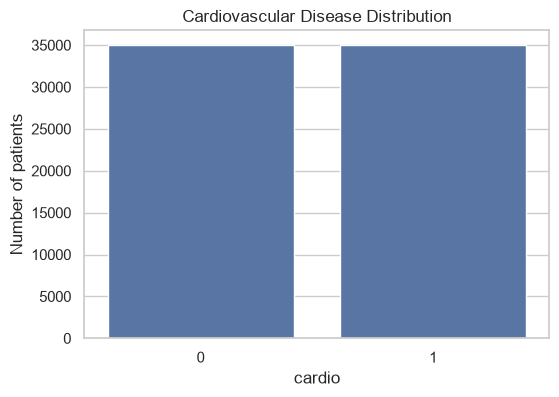

In [11]:
print(df["cardio"].value_counts())
print((df["cardio"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="cardio")
plt.title("Cardiovascular Disease Distribution")
plt.xlabel("cardio")
plt.ylabel("Number of patients")
plt.show()

Roughly balanced target (~50/50), so accuracy alone won't be a misleading metric here.

## 4. Numerical features

In [12]:
numerical_features = ["age", "height", "weight", "ap_hi", "ap_lo"]
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,70000.0,19468.865814,2467.251667,10798.0,17664.0,19703.0,21327.0,23713.0
height,70000.0,164.359229,8.210126,55.0,159.0,165.0,170.0,250.0
weight,70000.0,74.205690,14.395757,10.0,65.0,72.0,82.0,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.0,80.0,90.0,11000.0


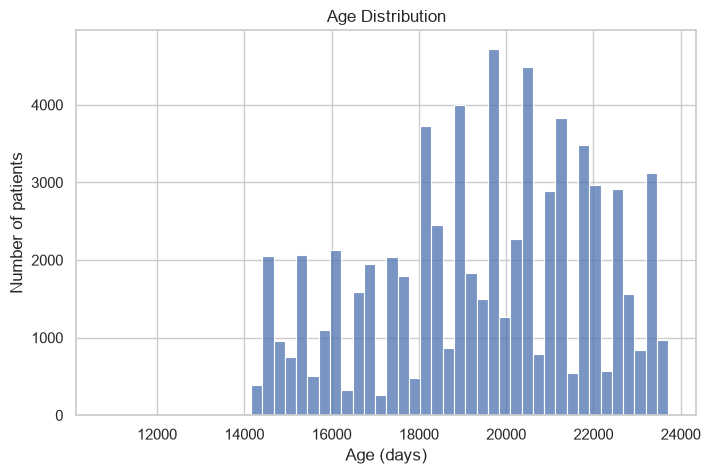

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=50)
plt.title("Age Distribution")
plt.xlabel("Age (days)")
plt.ylabel("Number of patients")
plt.show()

Age is stored in **days**, not years — needs converting before it's usable for reporting or modeling.

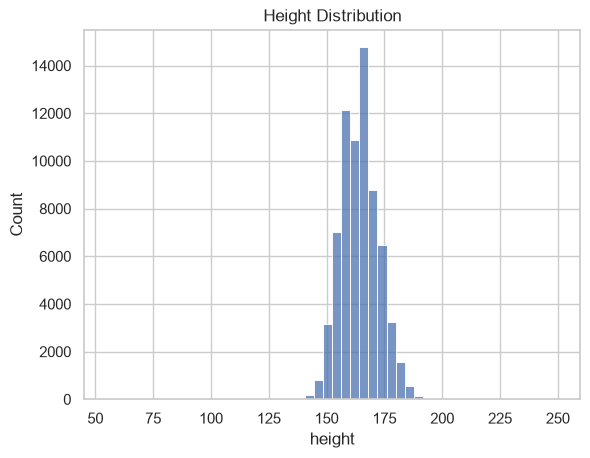

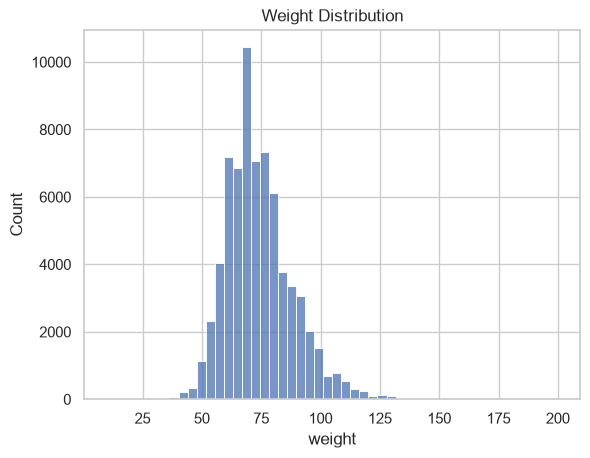

In [14]:
sns.histplot(df["height"], bins=50)
plt.title("Height Distribution")
plt.show()

sns.histplot(df["weight"], bins=50)
plt.title("Weight Distribution")
plt.show()

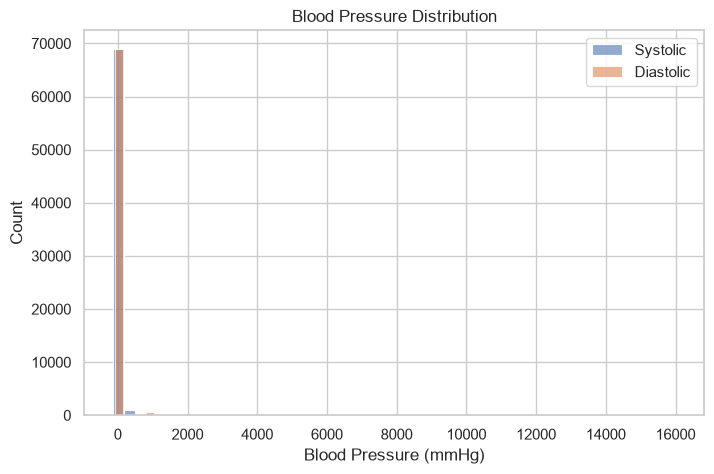

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="ap_hi", bins=50, label="Systolic", alpha=0.6)
sns.histplot(data=df, x="ap_lo", bins=50, label="Diastolic", alpha=0.6)

plt.title("Blood Pressure Distribution")
plt.xlabel("Blood Pressure (mmHg)")
plt.legend()
plt.show()

Both BP distributions have a long, unrealistic tail — checked properly in the data quality section below.

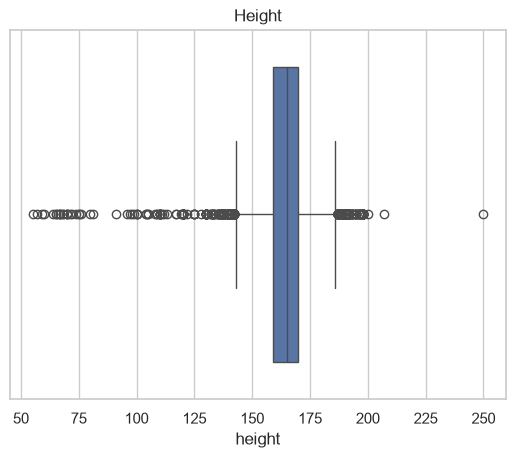

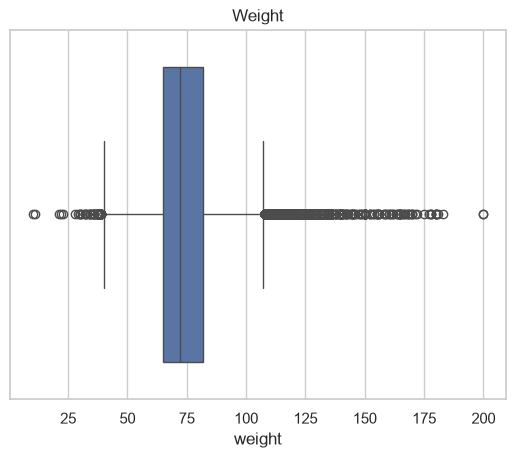

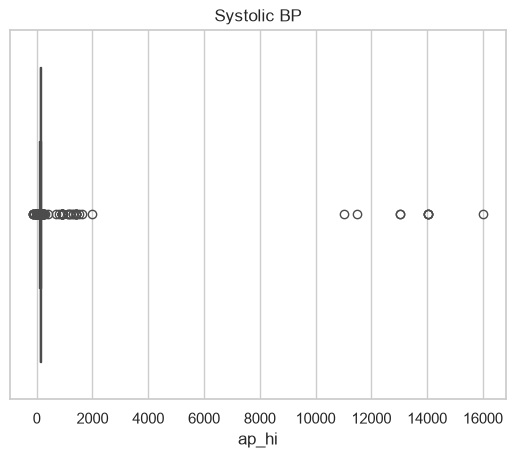

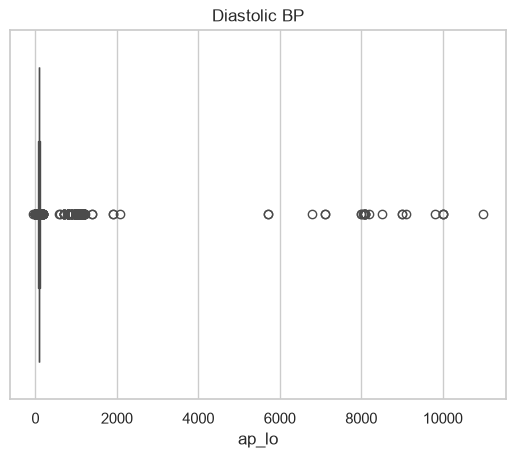

In [16]:
sns.boxplot(x=df["height"])
plt.title("Height")
plt.show()

sns.boxplot(x=df["weight"])
plt.title("Weight")
plt.show()

sns.boxplot(x=df["ap_hi"])
plt.title("Systolic BP")
plt.show()

sns.boxplot(x=df["ap_lo"])
plt.title("Diastolic BP")
plt.show()

## 5. Categorical features

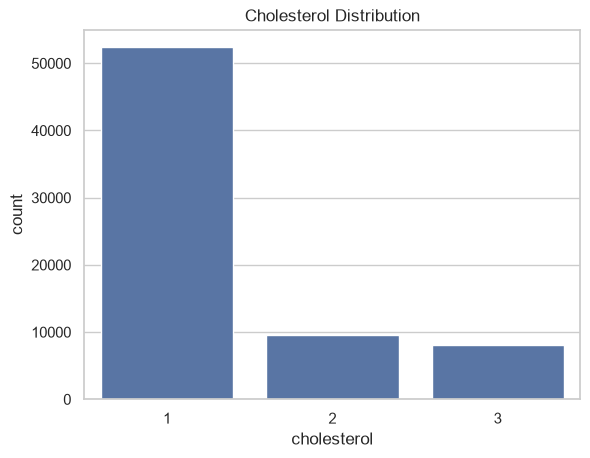

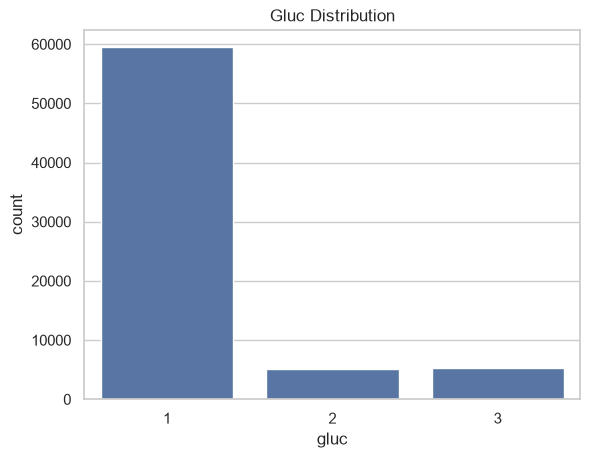

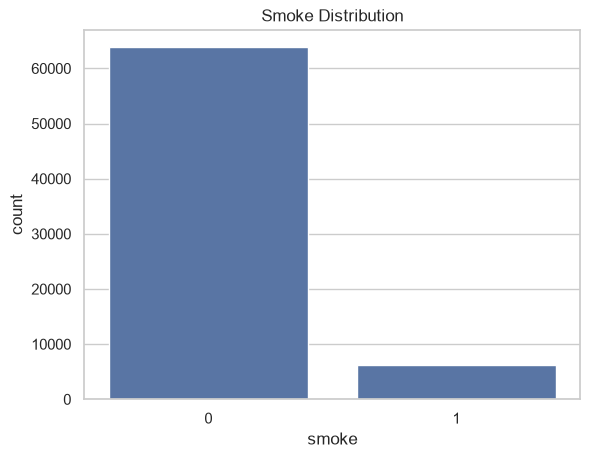

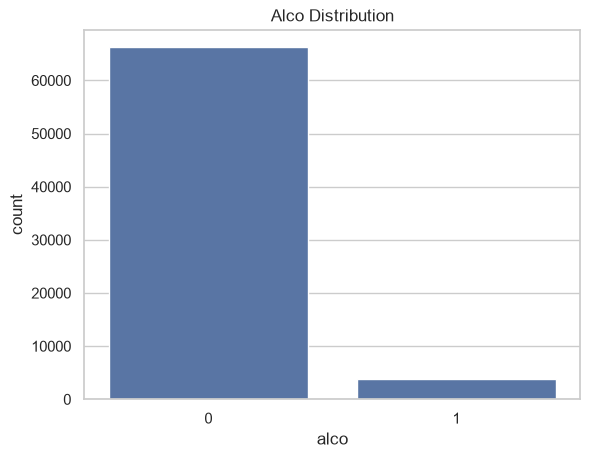

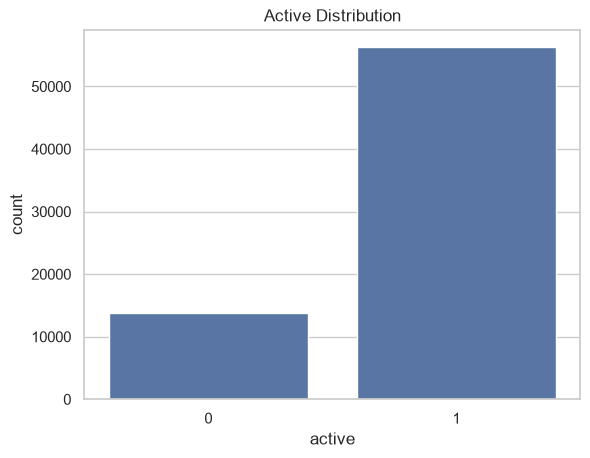

In [17]:
for feature in ["cholesterol", "gluc", "smoke", "alco", "active"]:
    sns.countplot(data=df, x=feature)

    plt.title(f"{feature.capitalize()} Distribution")
    plt.show()

cholesterol / gluc: 1 = normal, 2 = above normal, 3 = well above normal.

## 6. Correlation

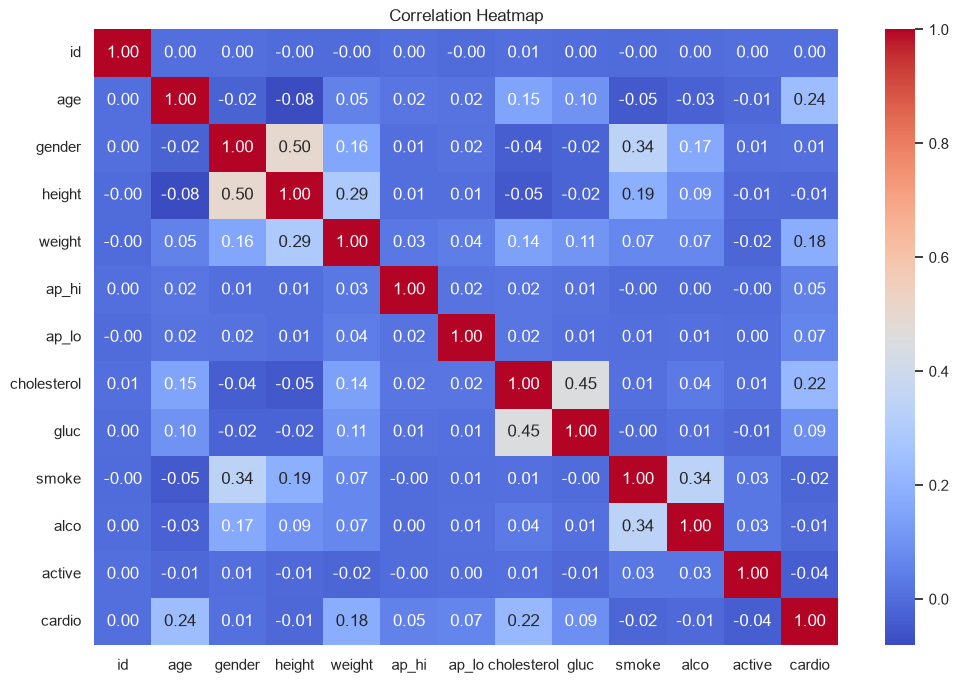

In [18]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 7. Features vs target

### Systolic BP

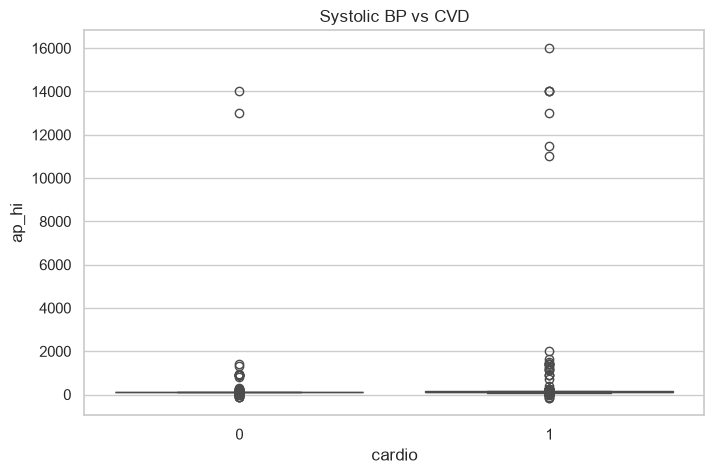

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="cardio", y="ap_hi")
plt.title("Systolic BP vs CVD")
plt.show()

### Weight

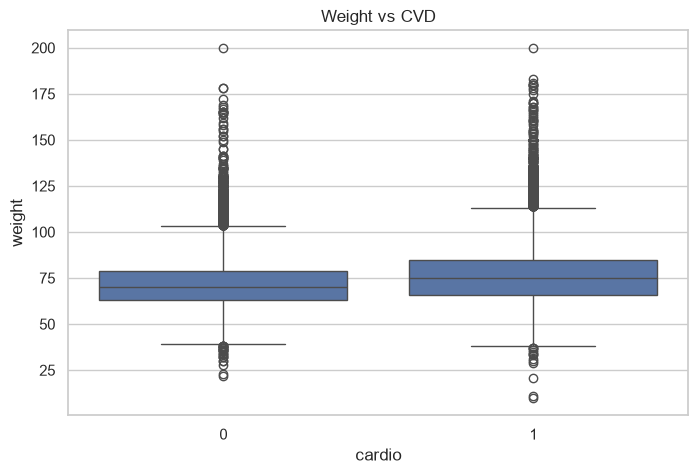

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="cardio", y="weight")
plt.title("Weight vs CVD")
plt.show()

### Cholesterol

In [21]:
cholesterol_cvd = pd.crosstab(df["cholesterol"], df["cardio"], normalize="index") * 100
cholesterol_cvd.round(2)

cardio,0,1
cholesterol,,
1,55.99,44.01
2,39.78,60.22
3,23.46,76.54


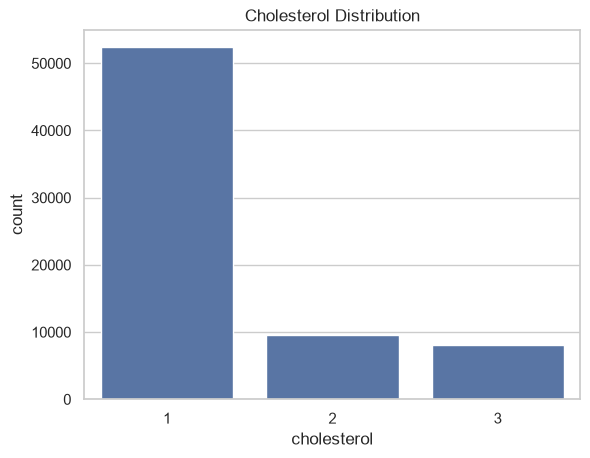

In [22]:
sns.countplot(data=df, x="cholesterol")
plt.title("Cholesterol Distribution")
plt.show()

### Glucose

In [23]:
glucose_cvd = pd.crosstab(df["gluc"], df["cardio"], normalize="index") * 100
glucose_cvd.round(2)

cardio,0,1
gluc,,
1,51.94,48.06
2,40.69,59.31
3,37.80,62.20


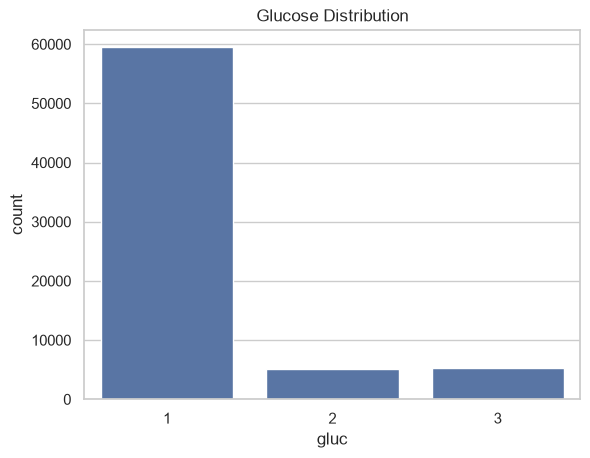

In [24]:
sns.countplot(data=df, x="gluc")
plt.title("Glucose Distribution")
plt.show()

### Physical Activity

In [25]:
activity_cvd = pd.crosstab(df["active"], df["cardio"], normalize="index") * 100
activity_cvd.round(2)

cardio,0,1
active,,
0,46.42,53.58
1,50.91,49.09


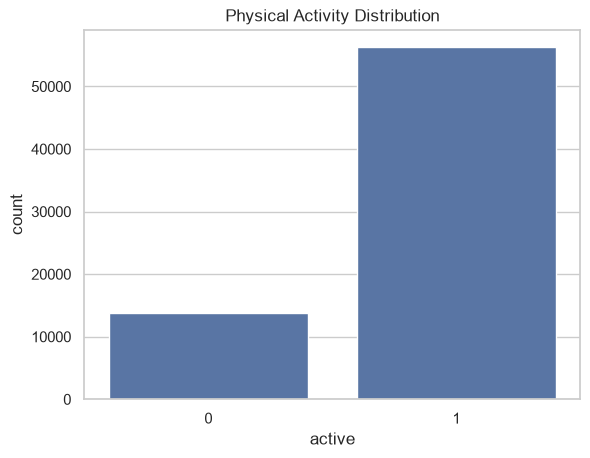

In [26]:
sns.countplot(data=df, x="active")
plt.title("Physical Activity Distribution")
plt.show()

## 8. Data quality — invalid values

Blood pressure and height/weight have obvious data-entry errors: negative BP, BP in the thousands, systolic lower than diastolic, and a handful of implausible heights/weights.

In [27]:
print("Systolic BP <= 0:", (df["ap_hi"] <= 0).sum())
print("Diastolic BP <= 0:", (df["ap_lo"] <= 0).sum())
print("Systolic BP > 300:", (df["ap_hi"] > 300).sum())
print("Diastolic BP > 200:", (df["ap_lo"] > 200).sum())
print("Systolic BP <= Diastolic BP:", (df["ap_hi"] <= df["ap_lo"]).sum())

print("\nHeight < 100 cm:", (df["height"] < 100).sum())
print("Height > 220 cm:", (df["height"] > 220).sum())
print("Weight < 30 kg:", (df["weight"] < 30).sum())
print("Weight > 200 kg:", (df["weight"] > 200).sum())

Systolic BP <= 0: 7
Diastolic BP <= 0: 22
Systolic BP > 300: 40
Diastolic BP > 200: 953
Systolic BP <= Diastolic BP: 1236

Height < 100 cm: 29
Height > 220 cm: 1
Weight < 30 kg: 7
Weight > 200 kg: 0


In [28]:
quality_summary = pd.DataFrame({
    "Issue": [
        "Systolic BP <= 0",
        "Diastolic BP <= 0",
        "Systolic BP > 300",
        "Diastolic BP > 200",
        "Systolic BP <= Diastolic BP",
        "Height < 100 cm",
        "Height > 220 cm",
        "Weight < 30 kg",
        "Weight > 200 kg"
    ],
    
    "Count": [
        (df["ap_hi"] <= 0).sum(),
        (df["ap_lo"] <= 0).sum(),
        (df["ap_hi"] > 300).sum(),
        (df["ap_lo"] > 200).sum(),
        (df["ap_hi"] <= df["ap_lo"]).sum(),
        (df["height"] < 100).sum(),
        (df["height"] > 220).sum(),
        (df["weight"] < 30).sum(),
        (df["weight"] > 200).sum()
    ]
})

quality_summary

,Issue,Count
0,Systolic BP <= 0,7
1,Diastolic BP <= 0,22
2,Systolic BP > 300,40
3,Diastolic BP > 200,953
4,Systolic BP <= Diastolic BP,1236
5,Height < 100 cm,29
6,Height > 220 cm,1
7,Weight < 30 kg,7
8,Weight > 200 kg,0


## 9. Clean the data

Dropping rows instead of imputing here, since these are measurement/entry errors rather than missing data — imputing a fake BP value would be worse than losing the row.

In [29]:
df_clean = df.copy()

valid_records = (
    (df_clean["ap_hi"] > 0) &
    (df_clean["ap_lo"] > 0) &
    (df_clean["ap_hi"] <= 300) &
    (df_clean["ap_lo"] <= 200) &
    (df_clean["ap_hi"] > df_clean["ap_lo"]) &
    (df_clean["height"] >= 100) &
    (df_clean["height"] <= 220) &
    (df_clean["weight"] >= 30) &
    (df_clean["weight"] <= 200)
)

df_clean = df_clean[valid_records].copy()

print("Original records:", len(df))
print("Cleaned records:", len(df_clean))
print("Removed:", len(df) - len(df_clean),
      f"({(len(df) - len(df_clean)) / len(df) * 100:.2f}%)")

Original records: 70000
Cleaned records: 68675
Removed: 1325 (1.89%)


In [30]:
print("Target distribution after cleaning:")
print(df_clean["cardio"].value_counts())
print((df_clean["cardio"].value_counts(normalize=True) * 100).round(2))

Target distribution after cleaning:
cardio
0    34699
1    33976
Name: count, dtype: int64
cardio
0    50.53
1    49.47
Name: proportion, dtype: float64


Class balance barely moved after cleaning, so the outlier removal isn't accidentally biasing the target.

## 10. Feature engineering

Three derived features from the data dictionary, plus MAP since it's a standard clinical BP-derived metric worth having alongside pulse pressure.

In [31]:
# Age in years (was in days)
df_clean["age_years"] = df_clean["age"] / 365.25

# BMI = weight(kg) / height(m)^2
df_clean["BMI"] = df_clean["weight"] / ((df_clean["height"] / 100) ** 2)

# Pulse pressure = systolic - diastolic
df_clean["pulse_pressure"] = df_clean["ap_hi"] - df_clean["ap_lo"]

# Mean arterial pressure
df_clean["MAP"] = (df_clean["ap_hi"] + 2 * df_clean["ap_lo"]) / 3

df_clean[["age_years", "BMI", "pulse_pressure", "MAP"]].describe().T

,count,mean,std,min,25%,50%,75%,max
age_years,68675.0,53.290610,6.756940,29.563313,48.343600,53.938398,58.381930,64.922656
BMI,68675.0,27.472735,5.351504,10.726644,23.875115,26.346494,30.119376,152.551775
pulse_pressure,68675.0,45.397991,11.760521,4.000000,40.000000,40.000000,50.000000,160.000000
MAP,68675.0,96.406519,11.106588,12.000000,93.333333,93.333333,103.333333,186.666667


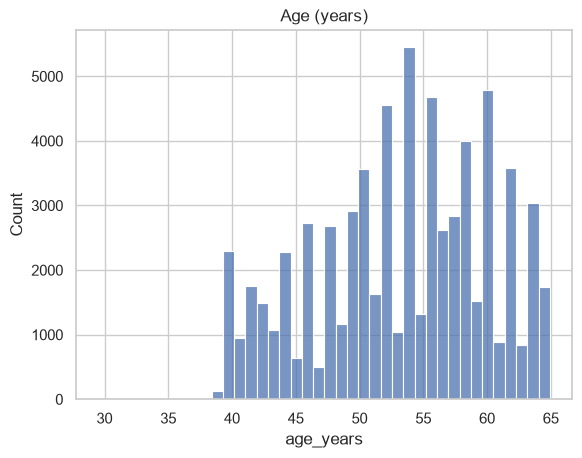

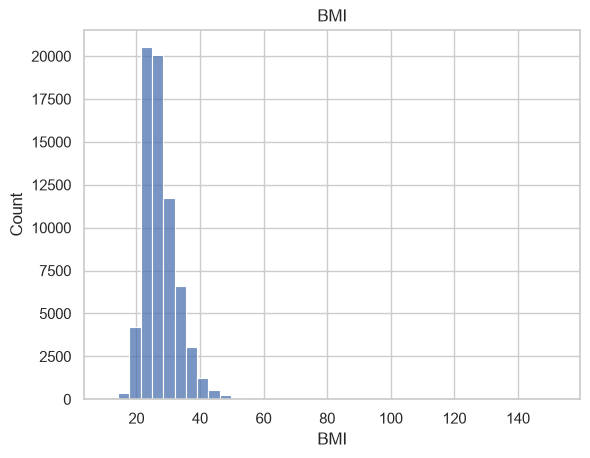

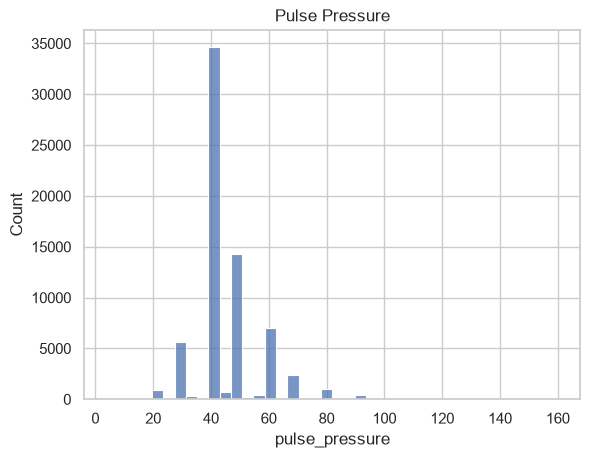

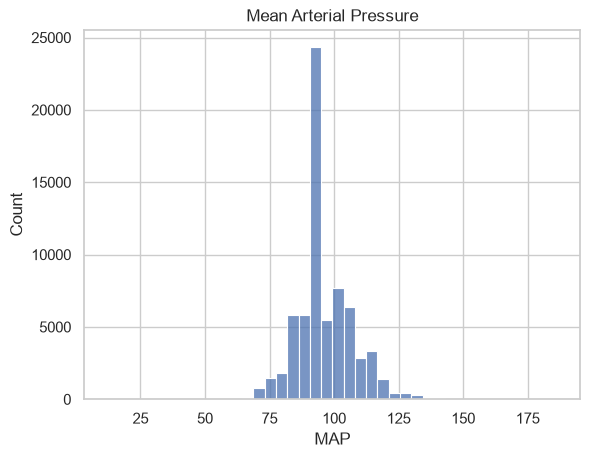

In [32]:
sns.histplot(df_clean["age_years"], bins=40)
plt.title("Age (years)")
plt.show()

sns.histplot(df_clean["BMI"], bins=40)
plt.title("BMI")
plt.show()

sns.histplot(df_clean["pulse_pressure"], bins=40)
plt.title("Pulse Pressure")
plt.show()

sns.histplot(df_clean["MAP"], bins=40)
plt.title("Mean Arterial Pressure")
plt.show()

## 11. Final model-ready dataset

In [33]:
model_df = df_clean.drop(columns=["id", "age"]).copy()

X = model_df.drop(columns=["cardio"])
y = model_df["cardio"]

print("Model dataset shape:", model_df.shape)
print("Features:", X.shape[1])
model_df.head()

Model dataset shape: (68675, 15)
Features: 14


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI,pulse_pressure,MAP
0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290,21.967120,30,90.000000
1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246,34.927679,50,106.666667
2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652,23.507805,60,90.000000
3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144,28.710479,50,116.666667
4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205,23.011177,40,73.333333


In [34]:
print("Missing values:", model_df.isnull().sum().sum())
print("Duplicate rows:", model_df.duplicated().sum())
print("\nFeatures used for prediction:")
for f in X.columns:
    print("-", f)

Missing values: 0
Duplicate rows: 24

Features used for prediction:
- gender
- height
- weight
- ap_hi
- ap_lo
- cholesterol
- gluc
- smoke
- alco
- active
- age_years
- BMI
- pulse_pressure
- MAP


In [35]:
print(df_clean.columns)

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years',
       'BMI', 'pulse_pressure', 'MAP'],
      dtype='object')


In [36]:
print(df_clean["gender"].value_counts())
print(df_clean["cholesterol"].value_counts())
print(df_clean["gluc"].value_counts())

gender
1    44736
2    23939
Name: count, dtype: int64
cholesterol
1    51500
2     9303
3     7872
Name: count, dtype: int64
gluc
1    58390
3     5216
2     5069
Name: count, dtype: int64


In [37]:
# Prepare final model dataset

df_encoded = df_clean.copy()

# Remove ID and original age
df_encoded = df_encoded.drop(columns=["id", "age"])

# Encode categorical features
df_encoded["gender"] = df_encoded["gender"].map({1: 0, 2: 1})

df_encoded = pd.get_dummies(
    df_encoded,
    columns=["cholesterol", "gluc"],
    drop_first=True,
    dtype=int
)

print("Final dataset shape:", df_encoded.shape)
print("Final columns:")
print(df_encoded.columns.tolist())

Final dataset shape: (68675, 17)
Final columns:
['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'BMI', 'pulse_pressure', 'MAP', 'cholesterol_2', 'cholesterol_3', 'gluc_2', 'gluc_3']


In [38]:
print("Final features:")
for column in df_encoded.columns:
    print("-", column)

Final features:
- gender
- height
- weight
- ap_hi
- ap_lo
- smoke
- alco
- active
- cardio
- age_years
- BMI
- pulse_pressure
- MAP
- cholesterol_2
- cholesterol_3
- gluc_2
- gluc_3


# Train Test Split

In [39]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=["cardio"])
y = df_encoded["cardio"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (48072, 16)
Validation set: (10301, 16)
Test set: (10302, 16)


In [40]:
print("Training target:")
print(y_train.value_counts(normalize=True).round(3))

print("\nValidation target:")
print(y_val.value_counts(normalize=True).round(3))

print("\nTest target:")
print(y_test.value_counts(normalize=True).round(3))

Training target:
cardio
0    0.505
1    0.495
Name: proportion, dtype: float64

Validation target:
cardio
0    0.505
1    0.495
Name: proportion, dtype: float64

Test target:
cardio
0    0.505
1    0.495
Name: proportion, dtype: float64


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [42]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,age_years,BMI,pulse_pressure,MAP,cholesterol_2,cholesterol_3,gluc_2,gluc_3
53727,-0.731680,-1.555515,-2.106875,-0.997095,0.912627,-0.30969,-0.23834,0.494553,-1.746904,-1.581764,-2.156567,0.024139,-0.395594,-0.359508,-0.282118,-0.285455
24178,-0.731680,0.325755,-0.778219,-0.997095,-0.132390,-0.30969,-0.23834,0.494553,-1.416336,-0.916368,-1.307365,-0.576210,-0.395594,-0.359508,-0.282118,-0.285455
32245,-0.731680,0.325755,0.830155,0.798169,-1.177407,-0.30969,-0.23834,0.494553,-1.439050,0.631488,2.089443,-0.276036,2.527846,-0.359508,-0.282118,-0.285455
19811,-0.731680,-1.053843,-0.218785,0.199748,-1.177407,-0.30969,-0.23834,-2.022029,1.054612,0.319618,1.240241,-0.576210,-0.395594,-0.359508,-0.282118,-0.285455
16154,1.366717,1.203681,-0.008997,-0.398674,-0.132390,-0.30969,-0.23834,0.494553,1.537688,-0.568723,-0.458163,-0.276036,-0.395594,-0.359508,-0.282118,-0.285455


In [43]:
print("Training mean:")
print(X_train_scaled.mean().round(2))

print("\nTraining standard deviation:")
print(X_train_scaled.std().round(2))

Training mean:
gender            0.0
height           -0.0
weight           -0.0
ap_hi            -0.0
ap_lo            -0.0
smoke             0.0
alco             -0.0
active            0.0
age_years        -0.0
BMI               0.0
pulse_pressure    0.0
MAP              -0.0
cholesterol_2     0.0
cholesterol_3    -0.0
gluc_2           -0.0
gluc_3            0.0
dtype: float64

Training standard deviation:
gender            1.0
height            1.0
weight            1.0
ap_hi             1.0
ap_lo             1.0
smoke             1.0
alco              1.0
active            1.0
age_years         1.0
BMI               1.0
pulse_pressure    1.0
MAP               1.0
cholesterol_2     1.0
cholesterol_3     1.0
gluc_2            1.0
gluc_3            1.0
dtype: float64


# XGBoost

In [44]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("XGBoost training completed.")

XGBoost training completed.


In [45]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# LightGBM

In [46]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)]
)

print("LightGBM training completed.")

c:\Users\deepa\Desktop\CVD-XAI\SKIT-AI-2023-2027-14\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


LightGBM training completed.


In [47]:
lgbm_pred = lgbm_model.predict(X_test)
lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]

# CatBoost

In [48]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val)
)

print("CatBoost training completed.")

CatBoost training completed.


In [49]:
cat_pred = cat_model.predict(X_test).ravel()
cat_prob = cat_model.predict_proba(X_test)[:, 1]

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [51]:
results = []

models = {
    "XGBoost": (xgb_pred, xgb_prob),
    "LightGBM": (lgbm_pred, lgbm_prob),
    "CatBoost": (cat_pred, cat_prob)
}

for name, (pred, prob) in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.7311,0.7516,0.6820,0.7151,0.7988
1,LightGBM,0.7309,0.7499,0.6843,0.7156,0.7985
2,CatBoost,0.7312,0.7513,0.6828,0.7154,0.7993


# XGBoost — Hyperparameter Tuning with Cross-Validation

In [52]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

print("XGBoost model created.")

XGBoost model created.


In [53]:
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5]
}

In [54]:
from sklearn.model_selection import RandomizedSearchCV

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Hyperparameter tuning completed.")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Hyperparameter tuning completed.


In [55]:
print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(xgb_search.best_score_, 4))

Best Parameters:
{'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.7}

Best Cross-Validation ROC-AUC:
0.8032


In [56]:
xgb_tuned = xgb_search.best_estimator_

print("Best XGBoost model selected.")

Best XGBoost model selected.


In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_val_pred = xgb_tuned.predict(X_val)
xgb_val_prob = xgb_tuned.predict_proba(X_val)[:, 1]

print("Validation Results")
print("------------------")
print("Accuracy :", round(accuracy_score(y_val, xgb_val_pred), 4))
print("Precision:", round(precision_score(y_val, xgb_val_pred), 4))
print("Recall   :", round(recall_score(y_val, xgb_val_pred), 4))
print("F1-Score :", round(f1_score(y_val, xgb_val_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val, xgb_val_prob), 4))

Validation Results
------------------
Accuracy : 0.7288
Precision: 0.7496
Recall   : 0.6784
F1-Score : 0.7122
ROC-AUC  : 0.7943


In [58]:
xgb_test_pred = xgb_tuned.predict(X_test)
xgb_test_prob = xgb_tuned.predict_proba(X_test)[:, 1]

print("Test Results")
print("------------")
print("Accuracy :", round(accuracy_score(y_test, xgb_test_pred), 4))
print("Precision:", round(precision_score(y_test, xgb_test_pred), 4))
print("Recall   :", round(recall_score(y_test, xgb_test_pred), 4))
print("F1-Score :", round(f1_score(y_test, xgb_test_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, xgb_test_prob), 4))

Test Results
------------
Accuracy : 0.7314
Precision: 0.7532
Recall   : 0.68
F1-Score : 0.7147
ROC-AUC  : 0.799


[[4069 1136]
 [1631 3466]]


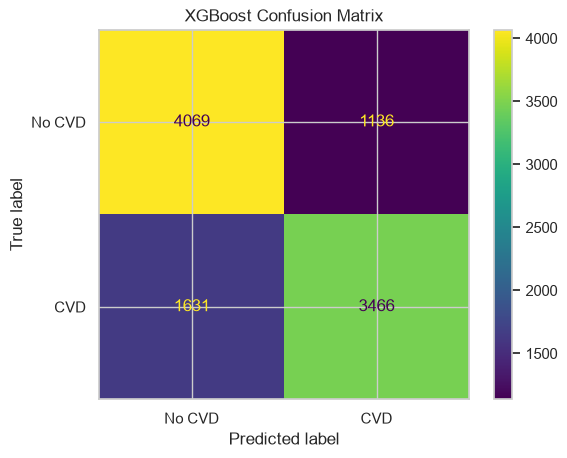

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, xgb_test_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No CVD", "CVD"]
).plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

In [60]:
from sklearn.metrics import precision_recall_curve

# Validation probabilities
xgb_val_prob = xgb_tuned.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_val,
    xgb_val_prob
)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_index = f1_scores.argmax()
best_threshold = thresholds[best_index]

print("Best Threshold:", round(best_threshold, 4))
print("Validation Precision:", round(precision[best_index], 4))
print("Validation Recall:", round(recall[best_index], 4))
print("Validation F1:", round(f1_scores[best_index], 4))

Best Threshold: 0.3462
Validation Precision: 0.656
Validation Recall: 0.8381
Validation F1: 0.7359


In [61]:
xgb_test_prob = xgb_tuned.predict_proba(X_test)[:, 1]

xgb_test_pred_threshold = (
    xgb_test_prob >= best_threshold
).astype(int)

In [62]:
print("XGBoost — Optimized Threshold Test Results")
print("--------------------------------------------")

print("Accuracy :",
      round(accuracy_score(y_test, xgb_test_pred_threshold), 4))

print("Precision:",
      round(precision_score(y_test, xgb_test_pred_threshold), 4))

print("Recall   :",
      round(recall_score(y_test, xgb_test_pred_threshold), 4))

print("F1-Score :",
      round(f1_score(y_test, xgb_test_pred_threshold), 4))

print("ROC-AUC  :",
      round(roc_auc_score(y_test, xgb_test_prob), 4))

XGBoost — Optimized Threshold Test Results
--------------------------------------------
Accuracy : 0.7018
Precision: 0.6561
Recall   : 0.8348
F1-Score : 0.7348
ROC-AUC  : 0.799


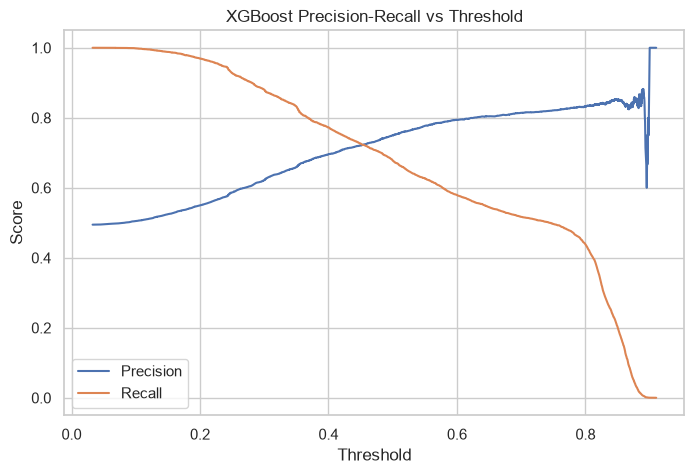

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost Precision-Recall vs Threshold")
plt.legend()
plt.show()

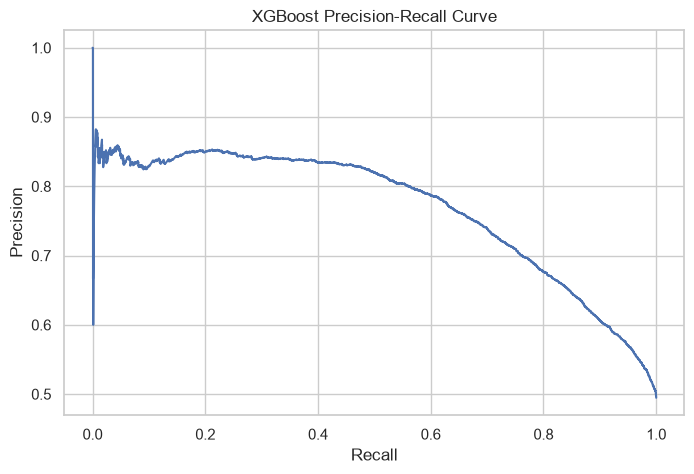

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")
plt.show()

# LightGBM — Hyperparameter Tuning with Cross-Validation

In [65]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

print("LightGBM model created.")

LightGBM model created.


In [66]:
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [-1, 3, 5, 7, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 50, 70],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_samples": [10, 20, 30, 50]
}

In [67]:
from sklearn.model_selection import RandomizedSearchCV

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_train, y_train)

print("LightGBM tuning completed.")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
LightGBM tuning completed.


In [68]:
print("Best Parameters:")
print(lgbm_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(lgbm_search.best_score_, 4))

Best Parameters:
{'subsample': 0.8, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 30, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

Best Cross-Validation ROC-AUC:
0.8034


In [69]:
lgbm_tuned = lgbm_search.best_estimator_

lgbm_val_pred = lgbm_tuned.predict(X_val)
lgbm_val_prob = lgbm_tuned.predict_proba(X_val)[:, 1]

print("Validation Results")
print("------------------")
print("Accuracy :", round(accuracy_score(y_val, lgbm_val_pred), 4))
print("Precision:", round(precision_score(y_val, lgbm_val_pred), 4))
print("Recall   :", round(recall_score(y_val, lgbm_val_pred), 4))
print("F1-Score :", round(f1_score(y_val, lgbm_val_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val, lgbm_val_prob), 4))

Validation Results
------------------
Accuracy : 0.7297
Precision: 0.7489
Recall   : 0.6825
F1-Score : 0.7142
ROC-AUC  : 0.7947


In [70]:
lgbm_test_pred = lgbm_tuned.predict(X_test)
lgbm_test_prob = lgbm_tuned.predict_proba(X_test)[:, 1]

print("Test Results")
print("------------")
print("Accuracy :", round(accuracy_score(y_test, lgbm_test_pred), 4))
print("Precision:", round(precision_score(y_test, lgbm_test_pred), 4))
print("Recall   :", round(recall_score(y_test, lgbm_test_pred), 4))
print("F1-Score :", round(f1_score(y_test, lgbm_test_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, lgbm_test_prob), 4))

Test Results
------------
Accuracy : 0.732
Precision: 0.7519
Recall   : 0.6839
F1-Score : 0.7163
ROC-AUC  : 0.7993


# CatBoost — Hyperparameter Tuning with Cross-Validation

In [71]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    random_seed=42,
    verbose=False
)

print("CatBoost model created.")

CatBoost model created.


In [72]:
param_grid = {
    "iterations": [100, 200, 300, 400, 500],
    "depth": [4, 5, 6, 7, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

In [73]:
from sklearn.model_selection import RandomizedSearchCV

cat_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

cat_search.fit(X_train, y_train)

print("CatBoost tuning completed.")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CatBoost tuning completed.


In [74]:
print("Best Parameters:")
print(cat_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(cat_search.best_score_, 4))

Best Parameters:
{'subsample': 0.9, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'iterations': 400, 'depth': 7}

Best Cross-Validation ROC-AUC:
0.8035


In [75]:
cat_tuned = cat_search.best_estimator_

cat_val_pred = cat_tuned.predict(X_val).ravel()
cat_val_prob = cat_tuned.predict_proba(X_val)[:, 1]

print("Validation Results")
print("------------------")
print("Accuracy :", round(accuracy_score(y_val, cat_val_pred), 4))
print("Precision:", round(precision_score(y_val, cat_val_pred), 4))
print("Recall   :", round(recall_score(y_val, cat_val_pred), 4))
print("F1-Score :", round(f1_score(y_val, cat_val_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val, cat_val_prob), 4))

Validation Results
------------------
Accuracy : 0.7272
Precision: 0.744
Recall   : 0.6839
F1-Score : 0.7127
ROC-AUC  : 0.7948


In [76]:
cat_test_pred = cat_tuned.predict(X_test).ravel()
cat_test_prob = cat_tuned.predict_proba(X_test)[:, 1]

print("Test Results")
print("------------")
print("Accuracy :", round(accuracy_score(y_test, cat_test_pred), 4))
print("Precision:", round(precision_score(y_test, cat_test_pred), 4))
print("Recall   :", round(recall_score(y_test, cat_test_pred), 4))
print("F1-Score :", round(f1_score(y_test, cat_test_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, cat_test_prob), 4))

Test Results
------------
Accuracy : 0.7324
Precision: 0.7512
Recall   : 0.6865
F1-Score : 0.7174
ROC-AUC  : 0.7998


# Clinical Model 4 — Deep Neural Network (DNN)

In [77]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [78]:
clinical_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

clinical_model.summary()

c:\Users\deepa\Desktop\CVD-XAI\SKIT-AI-2023-2027-14\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
clinical_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [80]:
history = clinical_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7208 - loss: 0.5654 - val_accuracy: 0.7248 - val_loss: 0.5565
Epoch 2/30
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7310 - loss: 0.5507 - val_accuracy: 0.7258 - val_loss: 0.5533
Epoch 3/30
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7338 - loss: 0.5480 - val_accuracy: 0.7261 - val_loss: 0.5530
Epoch 4/30
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7338 - loss: 0.5456 - val_accuracy: 0.7263 - val_loss: 0.5533
Epoch 5/30
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7342 - loss: 0.5445 - val_accuracy: 0.7277 - val_loss: 0.5518
Epoch 6/30
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7349 - loss: 0.5434 - val_accuracy: 0.7250 - val_loss: 0.5579
Epoch 7/30
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7352 - loss: 0.5426 - val_accuracy: 0.7307 - val_loss: 0.5502
Epoch 8/30
1503/1503 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7369 - loss: 0.5426 - 

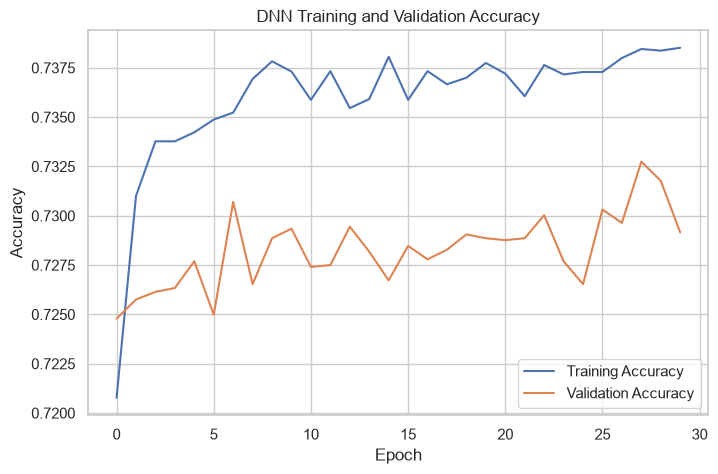

In [81]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DNN Training and Validation Accuracy")
plt.legend()
plt.show()

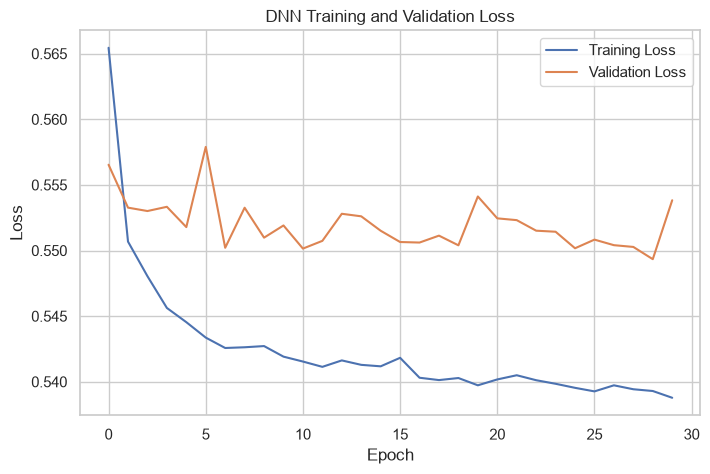

In [82]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DNN Training and Validation Loss")
plt.legend()
plt.show()

In [83]:
dnn_test_prob = clinical_model.predict(
    X_test_scaled,
    verbose=0
).ravel()

dnn_test_pred = (dnn_test_prob >= 0.5).astype(int)

In [84]:
print("DNN Test Results")
print("----------------")
print("Accuracy :",
      round(accuracy_score(y_test, dnn_test_pred), 4))

print("Precision:",
      round(precision_score(y_test, dnn_test_pred), 4))

print("Recall   :",
      round(recall_score(y_test, dnn_test_pred), 4))

print("F1-Score :",
      round(f1_score(y_test, dnn_test_pred), 4))

print("ROC-AUC  :",
      round(roc_auc_score(y_test, dnn_test_prob), 4))

DNN Test Results
----------------
Accuracy : 0.7299
Precision: 0.7368
Recall   : 0.7063
F1-Score : 0.7212
ROC-AUC  : 0.7978


[[3919 1286]
 [1497 3600]]


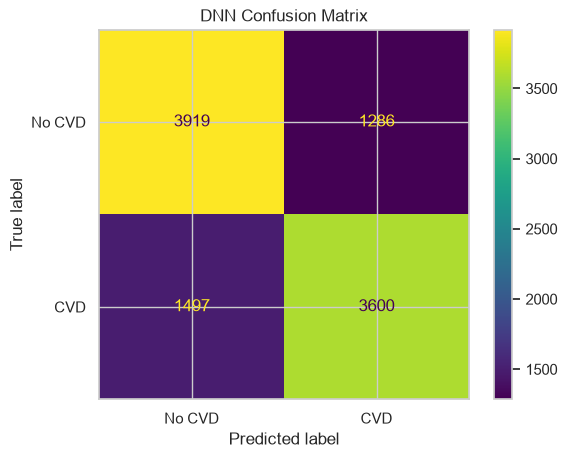

In [85]:
cm = confusion_matrix(y_test, dnn_test_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No CVD", "CVD"]
).plot()

plt.title("DNN Confusion Matrix")
plt.show()

In [91]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [90]:
print(classification_report(
    y_test,
    dnn_test_pred,
    target_names=["No CVD", "CVD"]
))

              precision    recall  f1-score   support

      No CVD       0.72      0.75      0.74      5205
         CVD       0.74      0.71      0.72      5097

    accuracy                           0.73     10302
   macro avg       0.73      0.73      0.73     10302
weighted avg       0.73      0.73      0.73     10302

